# TP 5 : IA & Sante - Ambulance (RL)
(SUJET)

**Objectif :** Implementer un agent Q-Learning qui apprend a naviguer une grille pour atteindre un patient.

---

## Principe de l'apprentissage par renforcement

Contrairement au supervised learning, l'agent n'a **pas d'exemples corrects** a imiter. Il apprend seul, en interagissant avec son environnement :

```
     +------------------+
     |   Environnement  |
     |  (la grille)     |
     +------------------+
          |        ^
    etat s|        | recompense r
  (position)       | nouvel etat s'
          v        |
     +------------------+
     |      Agent       |
     |  (l'ambulance)   |
     +------------------+
               |
           action a
        (haut/bas/gauche/droite)
```

- L'**agent** observe sa position courante et choisit une direction
- L'**environnement** lui retourne une recompense et sa nouvelle position
- L'agent repete cela sur de nombreux episodes et apprend progressivement quelles directions sont bonnes

**Ici :** l'ambulance decouvre la carte en se deplacant. Elle ne connait pas les obstacles a l'avance — elle les decouvre en les percutant (recompense negative) et apprend a les eviter.

---

## Le Q-Learning

L'agent maintient une **Q-Table** : tableau qui associe a chaque paire (position, action) une valeur estimee. Cette valeur represente "a quel point c'est une bonne idee de faire cette action depuis cette position".

Au debut, toutes les valeurs sont a 0 (l'agent ne sait rien). A chaque pas, il met a jour la valeur de l'action qu'il vient de prendre via la **formule de Bellman** :

$$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \bigl[r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a)\bigr]$$

| Symbole | Signification |
|---|---|
| $\alpha$ (learning rate) | A quel point on croit la nouvelle experience (0 = on ignore, 1 = on remplace tout) |
| $\gamma$ (discount factor) | Importance des recompenses futures vs immediates (0 = tres myope, 1 = tres prevoyant) |
| $r$ | Recompense immediate recue apres l'action |
| $\max Q(s', a')$ | Meilleure valeur future possible depuis le nouvel etat |

**Intuition :** la mise a jour calcule l'ecart entre ce qu'on esperait (`Q(s,a)` actuel) et ce qu'on a vraiment obtenu (`r + gamma * meilleur futur`). On corrige la Q-Table dans la direction de cet ecart, proportionnellement a alpha.

Apres suffisamment d'episodes, les cases proches du but auront des valeurs elevees, et l'agent pourra suivre le gradient de ces valeurs pour trouver le chemin optimal.

---

## La strategie epsilon-greedy

L'agent fait face a un dilemme fondamental a chaque pas : doit-il **explorer** (essayer quelque chose de nouveau) ou **exploiter** (faire ce qu'il sait deja etre bien) ?

- Si l'agent exploite toujours, il peut rester bloque sur une strategie sous-optimale et ne jamais decouvrir de meilleures routes
- Si l'agent explore toujours, il n'apprend jamais a utiliser ce qu'il a decouvert

La strategie **epsilon-greedy** resout ce compromis avec un seul parametre, **epsilon** (entre 0 et 1) :

> A chaque pas, l'agent tire un nombre aleatoire entre 0 et 1.
> Si ce nombre est inferieur a epsilon → il choisit une **action aleatoire** (exploration).
> Sinon → il choisit l'**action avec la plus grande valeur Q** pour cet etat (exploitation).

**Evolution d'epsilon :** on commence generalement avec un epsilon eleve (ex. 0.9) pour explorer largement au debut, puis on le diminue au fil des episodes pour privilegier de plus en plus l'exploitation une fois que l'agent a une bonne connaissance de l'environnement.

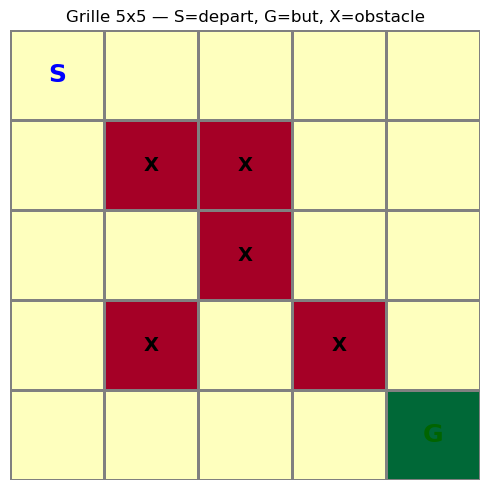

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

# === Environnement (fourni) ===
SIZE = 5
OBSTACLES = [(1,1), (1,2), (2,2), (3,1), (3,3)]
GOAL = (4, 4)
START = (0, 0)
NUM_ACTIONS = 4  # 0=Haut, 1=Bas, 2=Gauche, 3=Droite

def step(state, action):
    """
    Effectue une action depuis un etat et retourne (nouvel_etat, recompense, termine).

    Recompenses :
      +1.0  si on atteint le but GOAL
      -0.5  si on tape un mur ou un obstacle (on reste sur place)
       0.0  sinon (deplacement normal)
    """
    x, y = state
    moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    dx, dy = moves[action]
    next_state = (x + dx, y + dy)

    if (next_state[0] < 0 or next_state[0] >= SIZE or
            next_state[1] < 0 or next_state[1] >= SIZE or
            next_state in OBSTACLES):
        return state, -0.5, False
    if next_state == GOAL:
        return next_state, 1.0, True
    return next_state, 0.0, False

# Visualisation de la grille de depart
grid = np.zeros((SIZE, SIZE))
for obs in OBSTACLES:
    grid[obs] = -1
grid[GOAL] = 1

plt.figure(figsize=(5, 5))
sns.heatmap(grid, annot=False, cmap='RdYlGn', linewidths=1,
            linecolor='gray', cbar=False, vmin=-1, vmax=1)
plt.text(START[1]+0.5, START[0]+0.5, 'S', ha='center', va='center',
         fontsize=18, fontweight='bold', color='blue')
plt.text(GOAL[1]+0.5,  GOAL[0]+0.5,  'G', ha='center', va='center',
         fontsize=18, fontweight='bold', color='darkgreen')
for (ox, oy) in OBSTACLES:
    plt.text(oy+0.5, ox+0.5, 'X', ha='center', va='center',
             fontsize=14, fontweight='bold', color='black')
plt.title("Grille 5x5 — S=depart, G=but, X=obstacle")
plt.axis('off')
plt.tight_layout()
plt.show()

## Implementation du Q-Learning

L'environnement est fourni ci-dessus (`step`, constantes). A vous d'implementer l'agent.

**Ce que doit faire votre code, dans l'ordre :**

1. **Definir les hyperparametres** — taux d'apprentissage, discount factor, epsilon, nombre d'episodes

2. **Initialiser la Q-Table** — une structure vide au depart : l'agent ne sait rien

3. **Implementer la strategie epsilon-greedy** — choisir aleatoirement ou selon la Q-Table

4. **Ecrire la boucle d'entrainement** — a chaque episode, l'agent part de `START`, agit, observe la recompense, met a jour la Q-Table avec Bellman, jusqu'a atteindre `GOAL` ou depasser un nombre max de pas

5. **Afficher la Q-Table finale** — une heatmap de la valeur max par case montre ce que l'agent a appris (les cases proches du but doivent avoir des valeurs plus elevees)

6. **Verifier le chemin appris** — rejouer un episode sans exploration (epsilon=0) et afficher la sequence de cases parcourues

In [2]:
# 1. Hyperparametres
# learning_rate : combien on integre chaque nouvelle experience
# discount_factor : importance des recompenses futures (entre 0 et 1)
# epsilon : probabilite d'explorer plutot qu'exploiter
# num_episodes : nombre de parties jouees pour s'entrainer

# 2. Initialisation de la Q-Table
# Pour chaque position (i, j) non-obstacle, associer une liste de 4 valeurs (une par action)
# Toutes initialisees a 0.0

# 3. Strategie epsilon-greedy
# Fonction qui prend un etat et retourne une action
# -> avec proba epsilon : action aleatoire parmi les 4
# -> sinon : action avec la plus grande valeur Q pour cet etat

# 4. Boucle d'entrainement
# Pour chaque episode :
#   - Partir de START
#   - Repeter jusqu'au but ou max_steps :
#       - Choisir une action (epsilon-greedy)
#       - Appeler step(state, action) -> next_state, reward, done
#       - Mettre a jour Q-Table avec la formule de Bellman
#       - Avancer vers next_state
# Afficher la progression tous les N episodes

# 5. Visualisation : heatmap de max(Q(s)) pour chaque case
# Les cases proches du but doivent apparaitre en vert (valeur elevee)
# Les obstacles et cases non visitees en rouge/noir

# 6. Verification du chemin appris
# Rejouer un episode avec epsilon=0 (exploitation pure)
# Afficher la liste des cases visitees et le nombre de pas
